# Mamba-2 State Similarity 검증 실험

## 핵심 질문
**"같은 토픽의 문서는 비슷한 Type A head state를 갖는가?"**

```
만약 YES → state 자체를 retrieval key로 사용 가능
           (embedding 모델 없이 Mamba state로 검색 + 생성 통합)

만약 NO  → state는 value로만, 검색은 기존 embedding 방식 유지
           (그래도 prefill 비용 절감 contribution은 유효)
```

## 실험 설계
```
비교 대상:
  (A) 전체 state (모든 head flatten)
  (B) Type A head만 (A_disc > 0.99)
  (C) Type C head만 (A_disc < 0.50, 단기 기억)
  (D) 마지막 hidden state (residual stream, 비교 baseline)

측정:
  같은 토픽 문서 쌍 vs 다른 토픽 문서 쌍의 cosine similarity 분포
  → 분리가 잘 될수록 semantic index로 활용 가능
```

## 1. Import & 모델 로드

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from itertools import combinations
from scipy import stats
from transformers import AutoTokenizer
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from mamba_ssm.utils.generation import InferenceParams
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
MODEL_NAME = "state-spaces/mamba2-130m"

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
tokenizer.pad_token = tokenizer.eos_token

model = MambaLMHeadModel.from_pretrained(MODEL_NAME, device=device, dtype=torch.float32)
model.eval()

mixer      = model.backbone.layers[0].mixer
cfg        = model.config
N_LAYERS   = cfg.n_layer
D_STATE    = mixer.d_state
HEADDIM    = mixer.headdim
N_HEADS    = mixer.nheads

print(f"n_layers={N_LAYERS}, n_heads={N_HEADS}, headdim={HEADDIM}, d_state={D_STATE}")

n_layers=24, n_heads=24, headdim=64, d_state=128


## 2. Head Type 분류 (A_disc 기반)

In [4]:
def get_A_disc(model, n_layers):
    A_disc_all = []
    for i in range(n_layers):
        m      = model.backbone.layers[i].mixer
        A_log  = m.A_log.detach().cpu()
        dt     = F.softplus(m.dt_bias.detach().cpu())
        A_disc = torch.exp(-torch.exp(A_log) * dt)
        A_disc_all.append(A_disc.numpy())
    return np.array(A_disc_all)  # (n_layers, n_heads)


A_disc_all = get_A_disc(model, N_LAYERS)

SLOW_THR = 0.99
FAST_THR = 0.50

# layer별 head index 저장
slow_heads_per_layer = {}
fast_heads_per_layer = {}
for li in range(N_LAYERS):
    slow_heads_per_layer[li] = np.where(A_disc_all[li] >= SLOW_THR)[0].tolist()
    fast_heads_per_layer[li] = np.where(A_disc_all[li] <  FAST_THR)[0].tolist()

# 130m 기준 Layer 6가 slow head 제일 많음
# 여러 layer의 slow head를 모아서 쓸 수도 있음
print("Slow head counts per layer:")
for li in range(N_LAYERS):
    n_slow = len(slow_heads_per_layer[li])
    if n_slow > 0:
        print(f"  Layer {li:2d}: {n_slow} slow heads → {slow_heads_per_layer[li]}")

Slow head counts per layer:
  Layer  1: 6 slow heads → [2, 10, 17, 20, 21, 22]
  Layer  2: 14 slow heads → [1, 3, 4, 5, 6, 8, 10, 11, 12, 18, 19, 20, 22, 23]
  Layer  3: 2 slow heads → [17, 18]
  Layer  4: 17 slow heads → [0, 1, 2, 3, 5, 6, 7, 10, 11, 14, 15, 17, 18, 19, 20, 21, 22]
  Layer  5: 6 slow heads → [4, 5, 17, 18, 20, 23]
  Layer  6: 12 slow heads → [0, 1, 3, 4, 5, 8, 10, 12, 14, 19, 21, 22]
  Layer  7: 1 slow heads → [12]
  Layer  8: 1 slow heads → [22]
  Layer  9: 1 slow heads → [16]
  Layer 10: 12 slow heads → [2, 4, 6, 7, 8, 9, 11, 15, 18, 19, 21, 22]
  Layer 12: 1 slow heads → [7]
  Layer 13: 6 slow heads → [3, 8, 9, 13, 16, 21]
  Layer 14: 9 slow heads → [1, 7, 10, 11, 12, 16, 17, 21, 23]
  Layer 15: 4 slow heads → [1, 7, 11, 23]
  Layer 16: 8 slow heads → [1, 2, 6, 9, 11, 15, 17, 20]
  Layer 18: 1 slow heads → [7]
  Layer 19: 12 slow heads → [0, 1, 2, 3, 5, 6, 7, 11, 13, 17, 22, 23]
  Layer 20: 16 slow heads → [0, 1, 2, 4, 5, 7, 10, 11, 13, 14, 16, 17, 18, 19, 21, 22]


## 3. 토픽별 문서 준비

각 토픽당 5~8개 문서 → 토픽 내 similarity vs 토픽 간 similarity 비교

In [5]:
TOPIC_DOCS = {
    "AI_ML": [
        """Machine learning is a method of data analysis that automates analytical model building. It is based on the idea that systems can learn from data, identify patterns and make decisions with minimal human intervention. Deep learning uses neural networks with many layers to learn representations of data with multiple levels of abstraction. These methods have dramatically improved the state-of-the-art in speech recognition, visual object recognition, and object detection.""",
        """Artificial intelligence refers to the simulation of human intelligence in machines that are programmed to think like humans and mimic their actions. The term may also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving. Neural networks are computing systems vaguely inspired by the biological neural networks that constitute animal brains. An artificial neural network consists of layers of interconnected nodes or neurons.""",
        """Supervised learning is the machine learning task of learning a function that maps an input to an output based on example input-output pairs. It infers a function from labeled training data consisting of a set of training examples. Unsupervised learning is a type of algorithm that learns patterns from untagged data. The algorithm tries to learn the underlying structure or distribution in the data.""",
        """Reinforcement learning is an area of machine learning concerned with how intelligent agents ought to take actions in an environment in order to maximize cumulative reward. The environment is typically stated in the form of a Markov decision process. Deep reinforcement learning combines artificial neural networks with a reinforcement learning architecture that enables software-defined agents to learn the best actions possible in virtual environments.""",
        """Convolutional neural networks are a class of deep learning neural networks most commonly applied to analyze visual imagery. They use a mathematical operation called convolution in place of general matrix multiplication in at least one of their layers. Recurrent neural networks are a class of artificial neural networks where connections between nodes can create a cycle, allowing output from some nodes to affect subsequent input to the same nodes.""",
        """Transfer learning is a research problem in machine learning that focuses on storing knowledge gained while solving one problem and applying it to a different but related problem. The pre-trained model is then fine-tuned on the new task with a smaller dataset. This approach has become particularly powerful in natural language processing with the advent of large language models like BERT and GPT.""",
    ],

    "Space": [
        """The solar system consists of the Sun and everything that orbits around it, including planets, moons, asteroids, comets and meteoroids. The inner solar system includes Mercury, Venus, Earth and Mars, while the outer solar system includes Jupiter, Saturn, Uranus and Neptune. The Milky Way galaxy contains our solar system and is a barred spiral galaxy with a diameter of about 100,000 light-years.""",
        """Black holes are regions of spacetime where gravity is so strong that nothing, not even light or other electromagnetic waves, has enough speed to escape the event horizon. The theory of general relativity predicts that a sufficiently compact mass can deform spacetime to form a black hole. The boundary of no escape is called the event horizon. A black hole has a great effect on the fate and circumstances of an object crossing it.""",
        """The International Space Station is a modular space station in low Earth orbit. It is a multinational collaborative project involving five participating space agencies: NASA, Roscosmos, JAXA, ESA, and CSA. The station serves as a microgravity and space environment research laboratory in which scientific research is conducted in astrobiology, astronomy, meteorology, physics, and other fields.""",
        """Exoplanets are planets beyond our own solar system. Thousands have been discovered in the past two decades, mostly with NASA's Kepler Space Telescope. These worlds come in a huge variety of sizes and orbits. Some are gigantic planets hugging close to their parent stars while others are icy, some rocky. NASA and other agencies are looking for a special kind of planet: one that's the same size as Earth, orbiting a sun-like star in the habitable zone.""",
        """NASA's Mars exploration program has sent several missions to study the red planet. The Mars rovers including Curiosity and Perseverance have been exploring the Martian surface, analyzing rock and soil samples, and searching for signs of ancient life. Mars has a thin atmosphere composed mostly of carbon dioxide and has the largest volcano in the solar system, Olympus Mons, as well as the longest canyon, Valles Marineris.""",
        """Gravitational waves are ripples in the curvature of spacetime that are generated by accelerated masses and propagate as waves outward from their source at the speed of light. They were first directly detected in 2015 by the LIGO detector. The detection of gravitational waves opened a new window on the universe, enabling observation of merging black holes and neutron stars in ways never before possible.""",
    ],

    "Cooking": [
        """French cuisine is known throughout the world for its fine presentation, sophisticated flavor combinations, and use of rich sauces. Classic French cooking techniques include sauteing, braising, and flambeing. A traditional French meal might begin with soup or appetizers, followed by a main course of meat or fish, accompanied by vegetables, and finished with cheese and dessert. Wine pairing is considered an essential part of French dining culture.""",
        """Italian cuisine is characterized by its simplicity, with many dishes having only four to eight ingredients. Italian cooks rely chiefly on the quality of the ingredients rather than on elaborate preparation. Ingredients and dishes vary by region. Many dishes that were once regional have proliferated with variations throughout the country. Pizza, pasta, and various types of bread are staples of Italian cooking, along with olive oil, tomatoes, and fresh herbs.""",
        """Fermentation is the metabolic process that converts sugar to acids, gases, or alcohol. It occurs in yeast and bacteria, and also in oxygen-starved muscle cells, as in the case of lactic acid fermentation. In cooking, fermentation is used to produce bread, beer, wine, cheese, yogurt, and many other foods. The process involves microorganisms converting carbohydrates, such as starch and sugars, into alcohols and acids under anaerobic conditions.""",
        """Japanese cuisine emphasizes seasonal ingredients, presentation, and balance of flavor, texture, and appearance. Sushi, ramen, tempura, and sashimi are internationally recognized Japanese dishes. The cuisine makes extensive use of rice, noodles, and tofu, along with fresh seafood. Traditional Japanese cooking methods include grilling, steaming, simmering, and frying. Miso, soy sauce, and dashi are fundamental seasonings in Japanese cooking.""",
        """Baking is a method of preparing food that uses dry heat, typically in an oven, but can also be done in hot ashes or on hot stones. The most common baked item is bread but many other types of foods are baked. Heat is gradually transferred from the surface of cakes, cookies, and breads to their center. As heat travels through, it transforms batters and doughs into baked goods with a firm dry crust and a softer center.""",
        """Indian cuisine encompasses a wide variety of regional and traditional cuisines native to India. Given the diversity in soil, climate, culture, ethnic groups, and occupations, these cuisines vary substantially and use locally available spices, herbs, vegetables, and fruits. Indian cuisine is influenced by a 5000-year history of various groups and cultures interacting with the subcontinent. The use of spices like turmeric, cumin, coriander, and cardamom is fundamental to Indian cooking.""",
    ],

    "Sports": [
        """Football is a family of team sports that involve, to varying degrees, kicking a ball to score a goal. Unqualified, the word football normally means the form of football that is the most popular where the word is used. Sports commonly called football include association football, gridiron football, Australian rules football, rugby union, rugby league and Gaelic football. These sports involve two teams competing to move a ball into their opponent's goal.""",
        """Basketball is a team sport in which two teams, most commonly of five players each, opposing one another on a rectangular court, compete with the primary objective of shooting a basketball through the defender's hoop while preventing the opposing team from shooting through their own hoop. A field goal is worth two points, unless made from behind the three-point line, when it is worth three. After a foul, timed play stops and the player fouled gets one, two or three free-throw shots.""",
        """Tennis is a racket sport that can be played individually against a single opponent or between two teams of two players each. Each player uses a tennis racket that is strung with cord to strike a hollow rubber ball covered with felt over or around a net and into the opponent's court. The object of the game is to maneuver the ball in such a way that the opponent is not able to play a valid return.""",
        """Swimming is an individual or team racing sport that requires the use of one's entire body to move through water. The sport takes place in pools or open water. Competitive swimming is one of the most popular Olympic sports. Competitive swimming became popular in the nineteenth century. The goal of competitive swimming is to break personal or world records while beating competitors in any given event.""",
        """The Olympic Games are leading international sporting events featuring summer and winter sports competitions in which thousands of athletes from around the world participate in a variety of competitions. The Olympic Games are considered the world's foremost sports competition with more than 200 nations participating. The Games are normally held every four years, alternating between the Summer and Winter Olympics every two years in the four-year period.""",
        """Marathon running is a long-distance running event with an official distance of 42.195 kilometres. The marathon can be run as a road race or trail race. It is usually run as a road race. The event was instituted in commemoration of the fabled run of the Greek soldier Pheidippides, a messenger from the Battle of Marathon to Athens, who reported the victory. Training for a marathon typically requires months of preparation and gradual mileage buildup.""",
    ],

    "Music": [
        """Classical music is art music produced or rooted in the traditions of Western culture, including both liturgical and secular music. While a more precise term is also used to refer to the period from 1750 to 1820, this article is about the broad span of time from before the 6th century AD to the present day, which includes the Classical period and various other periods. The term classical music did not appear until the early 19th century.""",
        """Jazz is a music genre that originated in the African-American communities of New Orleans, Louisiana, United States, in the late 19th and early 20th centuries, with its roots in blues and ragtime. Jazz is characterized by swing and blue notes, complex chords, call and response vocals, polyrhythm and improvisation. Jazz has roots in West African cultural and musical expression, and in African-American music traditions including blues and ragtime.""",
        """Rock music is a broad genre of popular music that originated as rock and roll in the United States in the late 1940s and early 1950s, developing into a range of different styles in the mid-1960s and later, particularly in the United States and the United Kingdom. It has its roots in 1940s and 1950s rock and roll, a style which drew heavily from the genres of blues, rhythm and blues, and from country music.""",
        """Electronic music is a genre of music that employs electronic musical instruments, digital instruments, or circuitry-based music technology in its creation. It includes both music made using electronic sounds and music that uses electronic processing. The pioneers of electronic music used oscillators, ring modulators and tape machines. More recently, computers have become the primary tool for creating electronic music.""",
        """Music theory is the study of the practices and possibilities of music. The Oxford Companion to Music describes three interrelated uses of the term music theory. The first is what is otherwise called rudiments, currently taught as the elements of notation, of key signatures, of time signatures, of rhythmic notation, and so on. The second is the study of writings about music from ancient times onwards. The third is a more philosophical exploration of the nature of music.""",
        """Hip hop music, also called hip-hop or rap music, is a music genre developed in the United States by inner-city African Americans, Latino Americans and Caribbean Americans in the Bronx borough of New York City in the 1970s. It consists of a stylized rhythmic music that commonly accompanies rapping, a rhythmic and rhyming speech that is chanted. It developed as part of hip hop culture, a subculture defined by four key stylistic elements.""",
    ],
}

TOPICS   = list(TOPIC_DOCS.keys())
DOC_LEN  = 256  # 토큰 수 (T* ≈ 200~250에서 포화)

print(f"Topics: {TOPICS}")
print(f"Docs per topic: {[len(v) for v in TOPIC_DOCS.values()]}")
print(f"Doc length: {DOC_LEN} tokens")

Topics: ['AI_ML', 'Space', 'Cooking', 'Sports', 'Music']
Docs per topic: [6, 6, 6, 6, 6]
Doc length: 256 tokens


## 4. State 추출 함수

In [15]:
def get_ssm_states(model, input_ids, device):
    inf = InferenceParams(max_seqlen=input_ids.shape[1], max_batch_size=1)
    with torch.no_grad():
        out = model(input_ids.to(device), inference_params=inf)
    ssm = {k: v[1].squeeze(0).cpu().float()
           for k, v in inf.key_value_memory_dict.items()}
    # hidden state (residual stream)도 같이 추출
    hidden = out[0].squeeze(0)[-1].detach().cpu().float()  # 마지막 토큰
    return ssm, hidden


def extract_state_vectors(model, text, tokenizer, device,
                          doc_len, slow_heads_per_layer, fast_heads_per_layer):
    ids = tokenizer.encode(text, return_tensors='pt')
    while ids.shape[1] < doc_len:
        ids = torch.cat([ids, ids], dim=1)
    ids = ids[:, :doc_len]

    inf = InferenceParams(max_seqlen=ids.shape[1], max_batch_size=1)
    with torch.no_grad():
        out = model(ids.to(device), inference_params=inf)

    states = {k: v[1].squeeze(0).cpu().float()
              for k, v in inf.key_value_memory_dict.items()}

    # ── 기존: 마지막 토큰 ──────────────────────────────────────────────
    # hidden_last = out[0].squeeze(0)[-1].detach().cpu().float()

    # ── 변경: mean pooling (전체 토큰 평균) ───────────────────────────
    hidden_mean = out[0].squeeze(0).mean(dim=0).detach().cpu().float()

    # ── 추가: Layer 18의 그 single slow head ─────────────────────────
    # Layer 18 slow head index 확인 필요 (실험에서 n_slow=1)
    layer18_slow = slow_heads_per_layer.get(18, [])
    if layer18_slow:
        h18 = states[18][layer18_slow[0]].flatten().numpy()
    else:
        h18 = np.zeros(HEADDIM * D_STATE)

    # 기존 vector 계산 (그대로)
    all_vecs = []
    for li in range(N_LAYERS):
        all_vecs.append(states[li].flatten().numpy())
    all_state = np.concatenate(all_vecs)

    slow_vecs = []
    for li, heads in slow_heads_per_layer.items():
        for h in heads:
            slow_vecs.append(states[li][h].flatten().numpy())
    slow_state = np.concatenate(slow_vecs) if slow_vecs else np.zeros(1)

    fast_vecs = []
    for li, heads in fast_heads_per_layer.items():
        for h in heads:
            fast_vecs.append(states[li][h].flatten().numpy())
    fast_state = np.concatenate(fast_vecs) if fast_vecs else np.zeros(1)

    return {
        'all_state'   : all_state,
        'slow_state'  : slow_state,
        'fast_state'  : fast_state,
        'hidden_last' : out[0].squeeze(0)[-1].detach().cpu().float().numpy(),  # 기존
        'hidden_mean' : hidden_mean.numpy(),   # ← 새로운 baseline
        'layer18_head': h18,                   # ← 단일 head 분석
    }


In [17]:
# 전체 문서 처리
print("Extracting state vectors...")

doc_vectors = {}   # {topic: [{'all_state':..., 'slow_state':..., ...}, ...]}
doc_labels  = []   # [(topic, doc_idx), ...] 순서 추적용

for topic, docs in TOPIC_DOCS.items():
    doc_vectors[topic] = []
    for i, text in enumerate(docs):
        vecs = extract_state_vectors(
            model, text, tokenizer, device,
            DOC_LEN, slow_heads_per_layer, fast_heads_per_layer
        )
        doc_vectors[topic].append(vecs)
        doc_labels.append((topic, i))
    print(f"  {topic}: {len(docs)} docs done")

print(f"\nTotal docs: {len(doc_labels)}")
print(f"Vector dims - all: {doc_vectors[TOPICS[0]][0]['all_state'].shape[0]}, "
      f"slow: {doc_vectors[TOPICS[0]][0]['slow_state'].shape[0]}, "
      f"fast: {doc_vectors[TOPICS[0]][0]['fast_state'].shape[0]}, "
      f"hidden: {doc_vectors[TOPICS[0]][0]['hidden_mean'].shape[0]}")

Extracting state vectors...
  AI_ML: 6 docs done
  Space: 6 docs done
  Cooking: 6 docs done
  Sports: 6 docs done
  Music: 6 docs done

Total docs: 30
Vector dims - all: 4718592, slow: 1163264, fast: 655360, hidden: 50288


## 5. Cosine Similarity 행렬 계산

In [18]:
def build_similarity_matrix(doc_vectors, topics, vec_key):
    """모든 문서 쌍에 대한 cosine similarity 행렬 반환."""
    all_vecs = []
    labels   = []
    for topic in topics:
        for i, vecs in enumerate(doc_vectors[topic]):
            v = vecs[vec_key]
            # L2 normalize
            v = v / (np.linalg.norm(v) + 1e-9)
            all_vecs.append(v)
            labels.append(topic)

    mat = cosine_similarity(np.stack(all_vecs))
    return mat, labels


def compute_intra_inter_similarity(sim_mat, labels):
    """intra-topic (같은 토픽 쌍) vs inter-topic (다른 토픽 쌍) similarity."""
    n      = len(labels)
    intra  = []
    inter  = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra.append(sim_mat[i, j])
            else:
                inter.append(sim_mat[i, j])
    return np.array(intra), np.array(inter)


VEC_KEYS = ['all_state', 'slow_state', 'fast_state',
            'hidden_last', 'hidden_mean', 'layer18_head']
VEC_LABELS = {
    'all_state'   : 'All State',
    'slow_state'  : 'Type A (slow, all layers)',
    'fast_state'  : 'Type C (fast)',
    'hidden_last' : 'Hidden (last token)',
    'hidden_mean' : 'Hidden (mean pool)',    # ← 새로운 baseline
    'layer18_head': 'Layer18 single head',   # ← 집중 분석
}

results = {}
for key in VEC_KEYS:
    sim_mat, labels = build_similarity_matrix(doc_vectors, TOPICS, key)
    intra, inter    = compute_intra_inter_similarity(sim_mat, labels)
    t_stat, p_val   = stats.ttest_ind(intra, inter)
    results[key]    = {
        'sim_mat': sim_mat,
        'labels' : labels,
        'intra'  : intra,
        'inter'  : inter,
        't_stat' : t_stat,
        'p_val'  : p_val,
    }

# 요약 출력
print(f"{'Representation':<25} | {'intra mean':>11} | {'inter mean':>11} | "
      f"{'gap':>7} | {'p-value':>10}")
print("-" * 75)
for key in VEC_KEYS:
    r = results[key]
    gap = r['intra'].mean() - r['inter'].mean()
    print(f"{VEC_LABELS[key]:<25} | {r['intra'].mean():>11.4f} | "
          f"{r['inter'].mean():>11.4f} | {gap:>7.4f} | {r['p_val']:>10.2e}")

Representation            |  intra mean |  inter mean |     gap |    p-value
---------------------------------------------------------------------------
All State                 |      0.7067 |      0.6231 |  0.0837 |   2.41e-40
Type A (slow, all layers) |      0.7443 |      0.6555 |  0.0888 |   8.57e-71
Type C (fast)             |      0.4528 |      0.4466 |  0.0063 |   6.80e-01
Hidden (last token)       |      0.7414 |      0.7502 | -0.0088 |   9.08e-01
Hidden (mean pool)        |      0.9997 |      0.9994 |  0.0003 |   6.89e-37
Layer18 single head       |      0.8074 |      0.5272 |  0.2802 |  3.91e-104


## 6. 시각화

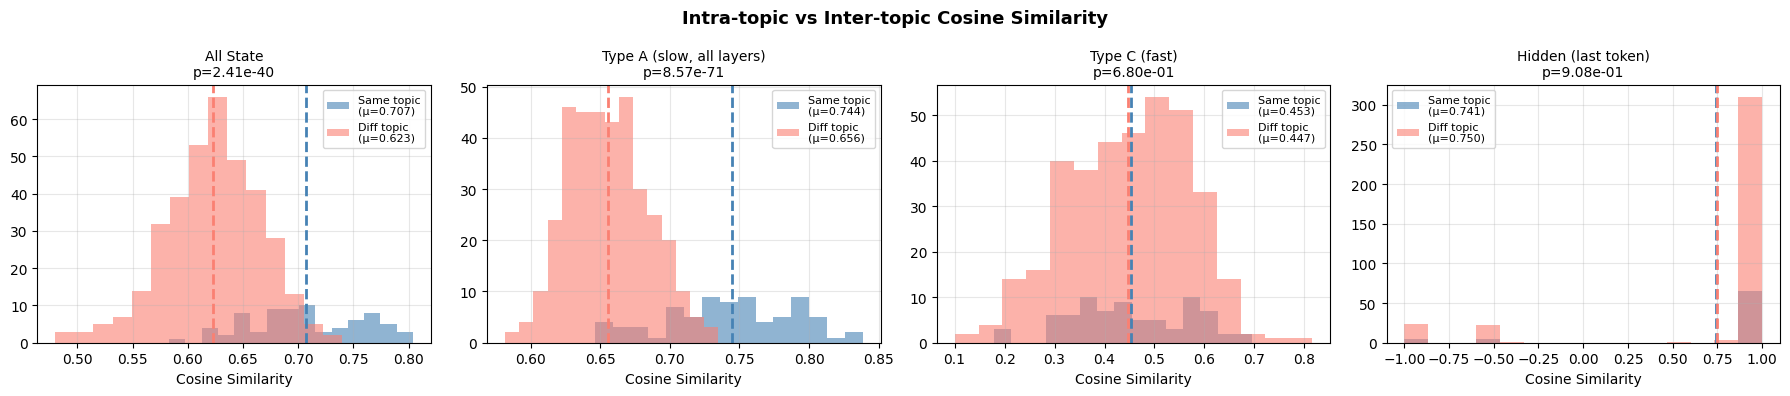

In [19]:
# ── Plot 1: intra vs inter similarity 분포 비교 ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

COLORS = {'intra': 'steelblue', 'inter': 'salmon'}

for ax, key in zip(axes, VEC_KEYS):
    r = results[key]
    ax.hist(r['intra'], bins=15, alpha=0.6, color=COLORS['intra'],
            label=f'Same topic\n(μ={r["intra"].mean():.3f})')
    ax.hist(r['inter'], bins=15, alpha=0.6, color=COLORS['inter'],
            label=f'Diff topic\n(μ={r["inter"].mean():.3f})')
    ax.axvline(r['intra'].mean(), color='steelblue', lw=2, ls='--')
    ax.axvline(r['inter'].mean(), color='salmon',    lw=2, ls='--')
    ax.set_title(f'{VEC_LABELS[key]}\np={r["p_val"]:.2e}', fontsize=10)
    ax.set_xlabel('Cosine Similarity')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Intra-topic vs Inter-topic Cosine Similarity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

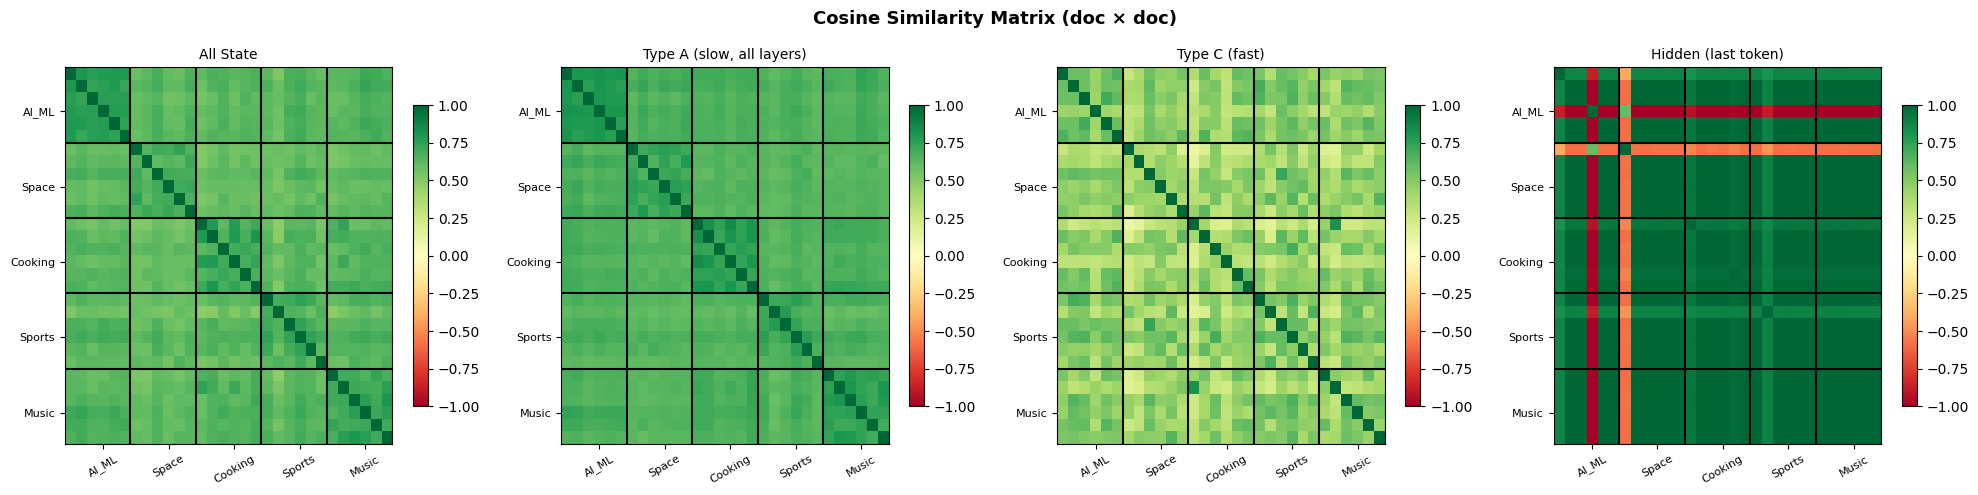

In [20]:
# ── Plot 2: Similarity matrix heatmap ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 토픽별로 정렬된 label 색상
topic_colors = plt.cm.tab10(np.linspace(0, 1, len(TOPICS)))
topic_color_map = {t: topic_colors[i] for i, t in enumerate(TOPICS)}

for ax, key in zip(axes, VEC_KEYS):
    r      = results[key]
    labels = r['labels']
    im = ax.imshow(r['sim_mat'], cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)

    # 토픽 경계선
    counts = [len(TOPIC_DOCS[t]) for t in TOPICS]
    boundaries = np.cumsum(counts[:-1]) - 0.5
    for b in boundaries:
        ax.axhline(b, color='black', lw=1.5)
        ax.axvline(b, color='black', lw=1.5)

    # 토픽 레이블
    tick_pos = np.cumsum([0] + counts[:-1]) + np.array(counts) / 2
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(TOPICS, rotation=30, fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(TOPICS, fontsize=8)
    ax.set_title(VEC_LABELS[key], fontsize=10)

plt.suptitle('Cosine Similarity Matrix (doc × doc)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

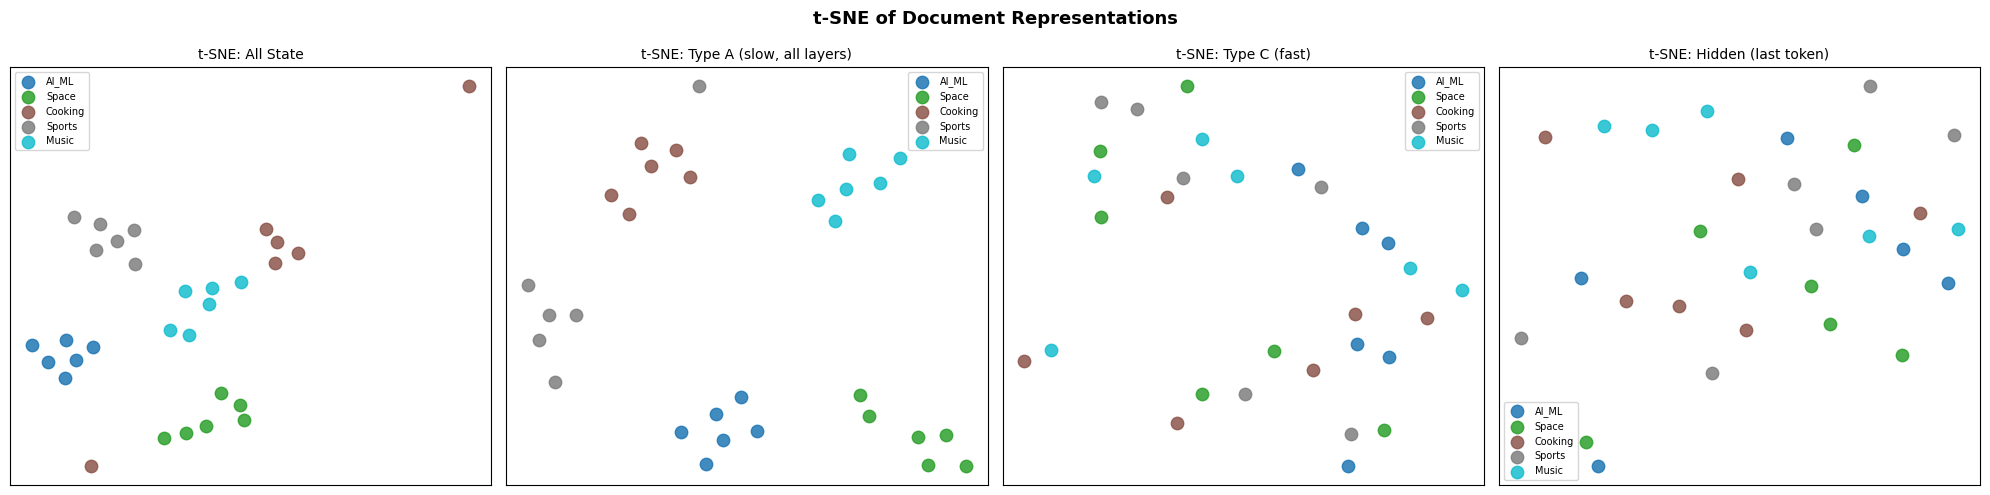

In [21]:
# ── Plot 3: t-SNE 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

topic_colors = plt.cm.tab10(np.linspace(0, 1, len(TOPICS)))
topic_color_map = {t: topic_colors[i] for i, t in enumerate(TOPICS)}

for ax, key in zip(axes, VEC_KEYS):
    all_vecs = []
    labels   = []
    for topic in TOPICS:
        for vecs in doc_vectors[topic]:
            v = vecs[key]
            v = v / (np.linalg.norm(v) + 1e-9)
            all_vecs.append(v)
            labels.append(topic)

    X = np.stack(all_vecs)

    # PCA로 먼저 차원 축소 후 t-SNE (문서 수 적으면 바로 t-SNE)
    if X.shape[1] > 50:
        X_pca = PCA(n_components=min(30, X.shape[0]-1)).fit_transform(X)
    else:
        X_pca = X

    tsne   = TSNE(n_components=2, perplexity=min(5, len(labels)-1),
                  random_state=42, n_iter=1000)
    X_2d   = tsne.fit_transform(X_pca)

    for topic in TOPICS:
        mask = [l == topic for l in labels]
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   color=topic_color_map[topic], label=topic, s=80, alpha=0.85)

    ax.set_title(f't-SNE: {VEC_LABELS[key]}', fontsize=10)
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE of Document Representations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

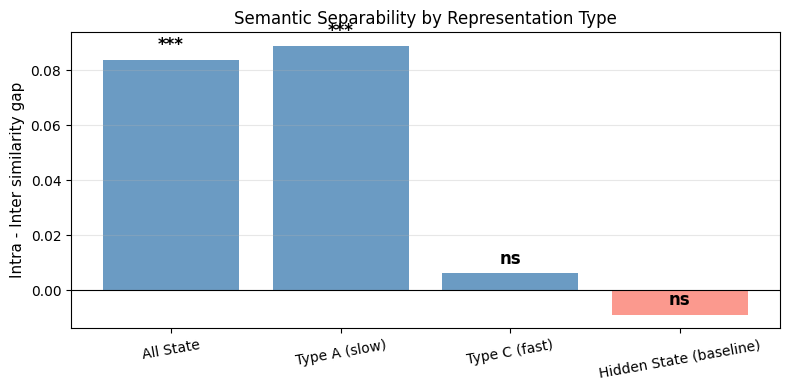


*** p<0.001  ** p<0.01  * p<0.05  ns: not significant


In [12]:
# ── Plot 4: gap 요약 bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

keys  = list(VEC_KEYS)
gaps  = [results[k]['intra'].mean() - results[k]['inter'].mean() for k in keys]
pvals = [results[k]['p_val'] for k in keys]
colors = ['steelblue' if g > 0 else 'salmon' for g in gaps]

bars = ax.bar([VEC_LABELS[k] for k in keys], gaps, color=colors, alpha=0.8)

for bar, pv in zip(bars, pvals):
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'ns'))
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            sig, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Intra - Inter similarity gap', fontsize=11)
ax.set_title('Semantic Separability by Representation Type', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('separability_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns: not significant")

## 7. Layer별 분석 - 어느 layer의 slow state가 가장 semantic한가

In [13]:
# 각 layer × head type별 gap 계산
print("Layer-wise separability (slow heads only):")
print(f"{'Layer':>6} | {'n_slow':>7} | {'intra':>8} | {'inter':>8} | {'gap':>7} | {'p-val':>10}")
print("-" * 60)

layer_results = {}
for li in range(N_LAYERS):
    slow_h = slow_heads_per_layer[li]
    if not slow_h:
        continue

    # 이 layer의 slow head만 추출해서 벡터 만들기
    all_vecs = []
    labels   = []
    for topic in TOPICS:
        for vecs_dict in doc_vectors[topic]:
            # get_ssm_states를 다시 돌리기엔 비용이 크니까
            # slow_state는 모든 layer concat이라 여기선 재추출 필요
            # → 간편하게 all_state에서 해당 layer 슬라이싱
            # all_state는 (n_layers × n_heads × headdim × d_state) flatten
            # 각 head의 벡터 크기 = headdim × d_state = 64×128 = 8192
            head_size = HEADDIM * D_STATE
            layer_start = li * N_HEADS * head_size
            for h in slow_h:
                head_start = layer_start + h * head_size
                v = vecs_dict['all_state'][head_start:head_start + head_size]
                all_vecs.append(v / (np.linalg.norm(v) + 1e-9))
                labels.append(topic)

    if len(all_vecs) < 2:
        continue

    sim_mat         = cosine_similarity(np.stack(all_vecs))
    intra, inter    = compute_intra_inter_similarity(sim_mat, labels)
    if len(intra) == 0 or len(inter) == 0:
        continue
    t_stat, p_val   = stats.ttest_ind(intra, inter)
    gap             = intra.mean() - inter.mean()

    layer_results[li] = {'intra': intra, 'inter': inter, 'gap': gap, 'p_val': p_val}
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    print(f"{li:>6} | {len(slow_h):>7} | {intra.mean():>8.4f} | "
          f"{inter.mean():>8.4f} | {gap:>7.4f} | {p_val:>10.2e} {sig}")

Layer-wise separability (slow heads only):
 Layer |  n_slow |    intra |    inter |     gap |      p-val
------------------------------------------------------------
     1 |       6 |   0.1260 |   0.1254 |  0.0005 |   9.32e-01 
     2 |      14 |   0.0449 |   0.0396 |  0.0053 |   2.35e-04 ***
     3 |       2 |   0.4422 |   0.4620 | -0.0199 |   4.66e-01 
     4 |      17 |   0.0188 |   0.0135 |  0.0054 |   1.54e-24 ***
     5 |       6 |   0.0996 |   0.0988 |  0.0008 |   8.81e-01 
     6 |      12 |   0.0302 |   0.0242 |  0.0060 |   4.66e-08 ***
     7 |       1 |   0.8877 |   0.8198 |  0.0678 |   5.05e-36 ***
     8 |       1 |   0.7998 |   0.7235 |  0.0763 |   9.18e-30 ***
     9 |       1 |   0.9657 |   0.9543 |  0.0114 |   1.62e-08 ***
    10 |      12 |   0.0135 |   0.0091 |  0.0044 |   1.46e-15 ***
    12 |       1 |   0.8107 |   0.7409 |  0.0698 |   9.03e-12 ***
    13 |       6 |   0.0774 |   0.0806 | -0.0031 |   4.72e-01 
    14 |       9 |   0.0509 |   0.0512 | -0.0004 |   8

## 8. 결과 해석 가이드

In [14]:
print("=" * 60)
print("RESULT INTERPRETATION")
print("=" * 60)

for key in VEC_KEYS:
    r   = results[key]
    gap = r['intra'].mean() - r['inter'].mean()
    sig = r['p_val'] < 0.05

    print(f"\n[{VEC_LABELS[key]}]")
    print(f"  intra-topic similarity : {r['intra'].mean():.4f} ± {r['intra'].std():.4f}")
    print(f"  inter-topic similarity : {r['inter'].mean():.4f} ± {r['inter'].std():.4f}")
    print(f"  gap                    : {gap:+.4f}")
    print(f"  p-value                : {r['p_val']:.4e} ({'significant' if sig else 'NOT significant'})")

    if gap > 0.05 and sig:
        print(f"  → ✅ GOOD: semantic separability 있음")
    elif gap > 0.01 and sig:
        print(f"  → ⚠️  WEAK: 약한 separability")
    else:
        print(f"  → ❌ NO: semantic separability 없음")

print()
print("Conclusion:")
slow_gap = results['slow_state']['intra'].mean() - results['slow_state']['inter'].mean()
hidden_gap = results['hidden']['intra'].mean() - results['hidden']['inter'].mean()

if slow_gap > hidden_gap * 0.5:
    print("  Type A state가 hidden state의 50% 이상 성능 → RAG key로 활용 가능성 있음")
elif slow_gap > 0:
    print("  Type A state에 semantic 정보는 있으나 hidden state보다 약함")
    print("  → hybrid 방식 (state + embedding) 검토")
else:
    print("  Type A state는 semantic similarity 표현 불가")
    print("  → state는 value로만, 검색은 기존 embedding 방식 유지")

RESULT INTERPRETATION

[All State]
  intra-topic similarity : 0.7067 ± 0.0508
  inter-topic similarity : 0.6231 ± 0.0430
  gap                    : +0.0837
  p-value                : 2.4110e-40 (significant)
  → ✅ GOOD: semantic separability 있음

[Type A (slow)]
  intra-topic similarity : 0.7443 ± 0.0464
  inter-topic similarity : 0.6555 ± 0.0285
  gap                    : +0.0888
  p-value                : 8.5666e-71 (significant)
  → ✅ GOOD: semantic separability 있음

[Type C (fast)]
  intra-topic similarity : 0.4528 ± 0.1193
  inter-topic similarity : 0.4466 ± 0.1195
  gap                    : +0.0063
  p-value                : 6.8013e-01 (NOT significant)
  → ❌ NO: semantic separability 없음

[Hidden State (baseline)]
  intra-topic similarity : 0.7414 ± 0.6020
  inter-topic similarity : 0.7502 ± 0.5918
  gap                    : -0.0088
  p-value                : 9.0758e-01 (NOT significant)
  → ❌ NO: semantic separability 없음

Conclusion:
  Type A state가 hidden state의 50% 이상 성능 → RAG k